# M3 — Hydrophobic SASA by MSM state (last 200 ns)

Reviewer M3: do long-lived near-native misfolded GDI1 states expose more hydrophobic
surface than the native state?


## Statistics

All statistics are **pooled over frames**: the mean is the frame mean, the 95% CI is a
bootstrap over frames, and the permutation test shuffles frames. Frames 75 ps apart are
strongly autocorrelated, so these intervals and p-values describe the frame sample rather
than independent observations of each state — they are narrow and small accordingly.

## Pipeline

1. Subset `SASA.npy` to the last 200 ns -> `(50, 2666, 451)`
2. Sum over hydrophobic residues -> `(50, 2666)`
3. Build state masks under both frame definitions; populations; save
4. Mean + 95% CI by bootstrap over frames
5. Permutation test vs native
6. Figure + report

**Read-only** on everything under `cg_sim_300K/`. All outputs go to `R1_analysis/M3_v2/outputs/`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import mdtraj as md
import matplotlib as mpl
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/storage/home/qzv5006/group/Research_data/Aging_project")
SIM_DIR = PROJECT_ROOT / "cg_sim_300K/sc_ent/14_P39958"
SASA_PATH = SIM_DIR / "analysis/SASA/SASA.npy"
MSM_PATH = SIM_DIR / "analysis/msm_results/msm_analysis_results.npz"
QG_PATH = SIM_DIR / "analysis/QG.npy"
PDB_PATH = SIM_DIR / "template/setup/P39958_clean.pdb"

OUT_DIR = PROJECT_ROOT / "R1_analysis/M3_v2/outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# --- analysis constants -------------------------------------------------------
N_RESIDUES = 451
N_LAST_200NS = 2666          # 200 ns at 75 ps/frame
FRAME_PS = 75.0

HYDROPHOBIC = {"ILE", "VAL", "LEU", "PHE", "CYS", "MET", "ALA", "GLY", "TRP"}

NATIVE_RAW = 5               # meta_dtrajs is 0-based; raw 5 is the native state
EXCLUDED_RAW = [1]           # reported state 2: 2 frames in this window
G_THRESHOLD = 0.0            # panel B rule: non-native frames need G > G_THRESHOLD

N_BOOT = 10_000
N_PERM = 10_000
BOOT_CHUNK = 200             # bootstrap resamples per chunk, to bound memory
SEED = 20260809

# reported label = raw + 1, matching the manuscript figures
to_reported = lambda raw: int(raw) + 1

mpl.rcParams.update({
    "font.size": 8, "axes.labelsize": 8, "axes.titlesize": 8,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.linewidth": 0.8, "pdf.fonttype": 42, "ps.fonttype": 42,
    "figure.dpi": 120, "savefig.dpi": 600, "savefig.bbox": "tight",
})

print("outputs ->", OUT_DIR)

outputs -> /storage/home/qzv5006/group/Research_data/Aging_project/R1_analysis/M3_v2/outputs


## Load inputs and check shapes

`SASA.npy` has 20000 frames but `meta_dtrajs` and `QG.npy` have 19999 — the last SASA
frame has no counterpart. It must be dropped **before** taking the last 200 ns, otherwise
the arrays end up offset by one frame.

In [2]:
sasa_mm = np.load(SASA_PATH, mmap_mode="r")                       # (50, 20000, 451), nm^2
meta_full = np.load(MSM_PATH, allow_pickle=True)["meta_dtrajs"]   # (50, 19999)
qg_full = np.load(QG_PATH)                                        # (50, 19999, 2) = [Q, G]

print(f"SASA        {sasa_mm.shape}  {sasa_mm.dtype}")
print(f"meta_dtrajs {meta_full.shape}  {meta_full.dtype}")
print(f"QG          {qg_full.shape}  {qg_full.dtype}")
print(f"raw state labels present: {np.unique(meta_full).tolist()}")

n_traj, n_frames_msm = meta_full.shape
assert sasa_mm.shape[0] == n_traj, "trajectory count mismatch"
assert sasa_mm.shape[1] == n_frames_msm + 1, "expected exactly one orphan SASA frame"
assert sasa_mm.shape[2] == N_RESIDUES
assert qg_full.shape[:2] == meta_full.shape
assert meta_full.max() == NATIVE_RAW, "native state is expected to be raw label 5"

print(f"\ntotal simulated time: {n_frames_msm * FRAME_PS / 1000:.1f} ns "
      f"({FRAME_PS:g} ps/frame)")
print(f"last-200ns window   : {N_LAST_200NS} frames "
      f"= {N_LAST_200NS * FRAME_PS / 1000:.0f} ns")

SASA        (50, 20000, 451)  float32
meta_dtrajs (50, 19999)  int64
QG          (50, 19999, 2)  float64
raw state labels present: [0, 1, 2, 3, 4, 5]

total simulated time: 1499.9 ns (75 ps/frame)
last-200ns window   : 2666 frames = 200 ns


## Hydrophobic residue mask

Residue names come from the all-atom reference structure `P39958_clean.pdb`.

In [3]:
top = md.load(str(PDB_PATH)).topology
assert top.n_residues == N_RESIDUES, f"PDB has {top.n_residues} residues, expected {N_RESIDUES}"

resnames = np.array([r.name for r in top.residues])
hydrophobic_mask = np.isin(resnames, list(HYDROPHOBIC))

print(f"residues            : {top.n_residues}")
print(f"hydrophobic residues: {hydrophobic_mask.sum()} "
      f"({100 * hydrophobic_mask.mean():.1f}%)")
print("composition:",
      {n: int((resnames[hydrophobic_mask] == n).sum()) for n in sorted(HYDROPHOBIC)})

residues            : 451
hydrophobic residues: 189 (41.9%)
composition: {'ALA': 21, 'CYS': 5, 'GLY': 31, 'ILE': 36, 'LEU': 40, 'MET': 10, 'PHE': 19, 'TRP': 3, 'VAL': 24}


/storage/group/epo2/default/qzv5006/miniconda3/envs/bioenv/lib/python3.13/site-packages/mdtraj/formats/pdb/pdbfile.py:214: UserWarning: Unlikely unit cell vectors detected in PDB file likely resulting from a dummy CRYST1 record. Discarding unit cell vectors.
  warnings.warn(


## Step 1-2 — Subset the last 200 ns and sum hydrophobic SASA

In [4]:
# drop the orphan last SASA frame FIRST, then take the last 200 ns
start = n_frames_msm - N_LAST_200NS
sasa_win = np.asarray(sasa_mm[:, start:n_frames_msm, :], dtype=np.float64)
meta_win = np.asarray(meta_full[:, -N_LAST_200NS:])
Q_win = qg_full[:, -N_LAST_200NS:, 0]
G_win = qg_full[:, -N_LAST_200NS:, 1]

print(f"SASA window {sasa_win.shape}")
print(f"meta window {meta_win.shape}")
print(f"G    window {G_win.shape}   range {G_win.min():.4f} - {G_win.max():.4f}")
print(f"Q    window {Q_win.shape}   range {Q_win.min():.4f} - {Q_win.max():.4f}"
      f"   ('Q >= 0' excludes {int((Q_win < 0).sum())} frames -> vacuous)")
assert sasa_win.shape[:2] == meta_win.shape

# Step 2: hydrophobic SASA per frame -> (50, 2666)
hyd_sasa = sasa_win[:, :, hydrophobic_mask].sum(axis=2)

print(f"\nhyd_sasa    {hyd_sasa.shape}")
print(f"range       {hyd_sasa.min():.1f} - {hyd_sasa.max():.1f} nm^2")

SASA window (50, 2666, 451)
meta window (50, 2666)
G    window (50, 2666)   range 0.0000 - 0.1190
Q    window (50, 2666)   range 0.4310 - 0.9980   ('Q >= 0' excludes 0 frames -> vacuous)



hyd_sasa    (50, 2666)
range       46.9 - 160.8 nm^2


## Step 3a — Frame masks and state populations

`Gfiltered` reproduces panel B: non-native states keep only `G > 0` frames, native keeps
everything. `allframes` keeps every assigned frame. The `pop_panelB` column should
reproduce the published 4.6 / 0.0 / 2.4 / 22 / 8.2 / 62.8 %.

In [5]:
raw_states = np.unique(meta_full).tolist()
NATIVE_REP = to_reported(NATIVE_RAW)
ANALYZED = [to_reported(r) for r in raw_states if r not in EXCLUDED_RAW]
SCHEMES = ("Gfiltered",)              # SASA results are reported for this frame set only
_POP_SCHEMES = ("Gfiltered", "allframes")   # both needed for the population table


def state_mask(raw, scheme):
    """Boolean (50, 2666) mask of frames belonging to `raw` under a frame scheme."""
    base = meta_win == raw
    if scheme == "allframes" or raw == NATIVE_RAW:
        return base
    return base & (G_win > G_THRESHOLD)


masks = {s: {raw: state_mask(raw, s) for raw in raw_states} for s in _POP_SCHEMES}

n_all = sum(int(masks["allframes"][r].sum()) for r in raw_states)
n_gf = sum(int(masks["Gfiltered"][r].sum()) for r in raw_states)

pop_rows = []
for raw in raw_states:
    n_a = int(masks["allframes"][raw].sum())
    n_g = int(masks["Gfiltered"][raw].sum())
    pop_rows.append({
        "state_raw": raw,
        "state_reported": to_reported(raw),
        "n_frames_all": n_a,
        "pop_all": n_a / n_all,
        "n_frames_Gfiltered": n_g,
        "pop_panelB": n_g / n_gf,
        "frac_frames_kept": n_g / n_a if n_a else np.nan,
        "n_traj": int((masks["allframes"][raw].sum(axis=1) > 0).sum()),
    })

population = pd.DataFrame(pop_rows)
population.to_csv(OUT_DIR / "state_population.csv", index=False)

print(f"frames discarded by G > {G_THRESHOLD:g}: {n_all - n_gf} of {n_all} "
      f"({100 * (n_all - n_gf) / n_all:.1f}%)")
print("published panel B: [0.046 0.    0.024 0.22  0.082 0.628]")
print("this calculation :", np.round(population["pop_panelB"].to_numpy(), 4))
population.round(4)

frames discarded by G > 0: 18813 of 133300 (14.1%)
published panel B: [0.046 0.    0.024 0.22  0.082 0.628]
this calculation : [0.0459 0.     0.0235 0.2204 0.0823 0.6278]


,state_raw,state_reported,n_frames_all,pop_all,n_frames_Gfiltered,pop_panelB,frac_frames_kept,n_traj
0,0,1,21315,0.1599,5252,0.0459,0.2464,8
1,1,2,2,0.0000,2,0.0000,1.0000,1
2,2,3,5441,0.0408,2691,0.0235,0.4946,22
3,3,4,25237,0.1893,25237,0.2204,1.0000,10
4,4,5,9426,0.0707,9426,0.0823,1.0000,10
5,5,6,71879,0.5392,71879,0.6278,1.0000,29


## Step 3b — Group hydrophobic SASA by state and save

State 2 (raw 1) is treated as **not populated in the final 200 ns** and is absent from all
comparisons, tables and figures. Its raw frame count is still written to
`state_population.csv` so the exclusion stays auditable.

In [6]:
def group_by_state(scheme):
    """-> dict: reported label -> 1D array of pooled frame values."""
    return {to_reported(raw): hyd_sasa[masks[scheme][raw]] for raw in raw_states}


frames_by = {s: group_by_state(s) for s in SCHEMES}

np.savez_compressed(
    OUT_DIR / "hyd_sasa_by_state.npz",
    **{f"{scheme}_state_{rep}": arr
       for scheme, d in frames_by.items() for rep, arr in d.items()},
)

print(f"analyzed states (reported): {ANALYZED}   native = {NATIVE_REP}")
for scheme in SCHEMES:
    print(f"\n{scheme}:")
    for rep in sorted(frames_by[scheme]):
        print(f"  state {rep}: {len(frames_by[scheme][rep]):>6d} frames")

analyzed states (reported): [1, 3, 4, 5, 6]   native = 6

Gfiltered:
  state 1:   5252 frames
  state 2:      2 frames
  state 3:   2691 frames
  state 4:  25237 frames
  state 5:   9426 frames
  state 6:  71879 frames


## Step 4 — Mean and 95% CI by bootstrap over frames

Percentile bootstrap resampling frames with replacement. Resampling is chunked so the
index array stays small for states with tens of thousands of frames.

In [7]:
def bootstrap_ci(values, n_boot=N_BOOT, seed=SEED, alpha=0.05, chunk=BOOT_CHUNK):
    """Percentile bootstrap CI for the mean, resampling frames."""
    values = np.asarray(values, dtype=float)
    n = len(values)
    if n < 2:
        return np.nan, np.nan
    rng = np.random.default_rng(seed)
    boot = np.empty(n_boot)
    done = 0
    while done < n_boot:
        k = min(chunk, n_boot - done)
        idx = rng.integers(0, n, size=(k, n))
        boot[done:done + k] = values[idx].mean(axis=1)
        done += k
    return tuple(np.percentile(boot, [100 * alpha / 2, 100 * (1 - alpha / 2)]))


def summarize(scheme):
    rows = []
    for rep in ANALYZED:
        v = frames_by[scheme][rep]
        lo, hi = bootstrap_ci(v)
        rows.append({
            "scheme": scheme,
            "state_raw": rep - 1,
            "state_reported": rep,
            "is_native": rep == NATIVE_REP,
            "n_frames": len(v),
            "mean": v.mean(),
            "sd": v.std(ddof=1) if len(v) > 1 else np.nan,
            "median": np.median(v),
            "ci95_low": lo,
            "ci95_high": hi,
        })
    return pd.DataFrame(rows).sort_values("state_reported")


summary = pd.concat([summarize(s) for s in SCHEMES], ignore_index=True)
summary.to_csv(OUT_DIR / "state_summary.csv", index=False)
summary.round(2)

,scheme,state_raw,state_reported,is_native,n_frames,mean,sd,median,ci95_low,ci95_high
0,Gfiltered,0,1,False,5252,134.61,7.02,134.73,134.42,134.80
1,Gfiltered,2,3,False,2691,78.56,5.23,78.92,78.36,78.75
2,Gfiltered,3,4,False,25237,58.22,2.88,58.05,58.18,58.25
3,Gfiltered,4,5,False,9426,58.78,3.30,58.42,58.71,58.84
4,Gfiltered,5,6,True,71879,56.53,2.59,56.37,56.51,56.55


## Step 5 — Permutation test vs native

Frames of each state are shuffled against native frames and the difference in means
recomputed. p is `(1 + #{perm >= obs}) / (1 + n_perm)`, so it is never exactly zero; with
tens of thousands of frames it will generally sit at the `1/(1+n_perm)` floor.

In [8]:
def permutation_test(x, y, n_perm=N_PERM, seed=SEED):
    """Two-sample permutation test on the difference of means (x - y)."""
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    n_x, n_y = len(x), len(y)
    if n_x < 2 or n_y < 2:
        return np.nan, np.nan, np.nan

    rng = np.random.default_rng(seed)
    observed = x.mean() - y.mean()
    combined = np.concatenate([x, y])
    total = combined.sum()

    ge_two, ge_greater = 0, 0
    for _ in range(n_perm):
        s = rng.permutation(combined)[:n_x].sum()
        diff = s / n_x - (total - s) / n_y
        ge_two += abs(diff) >= abs(observed)
        ge_greater += diff >= observed

    return observed, (1 + ge_two) / (1 + n_perm), (1 + ge_greater) / (1 + n_perm)


def compare_to_native(scheme):
    rows = []
    nat = frames_by[scheme][NATIVE_REP]
    for rep in ANALYZED:
        if rep == NATIVE_REP:
            continue
        x = frames_by[scheme][rep]
        obs, p2, pg = permutation_test(x, nat)
        rows.append({
            "scheme": scheme,
            "state_raw": rep - 1,
            "state_reported": rep,
            "n_frames": len(x),
            "n_native_frames": len(nat),
            "mean_diff_vs_native": obs,
            "percent_vs_native": 100 * obs / nat.mean(),
            "p_two_sided": p2,
            "p_greater": pg,
            "p_floor": 1 / (1 + N_PERM),
        })
    return pd.DataFrame(rows).sort_values("state_reported")


perm = pd.concat([compare_to_native(s) for s in SCHEMES], ignore_index=True)
perm.to_csv(OUT_DIR / "permutation_tests.csv", index=False)
perm.round(5)

,scheme,state_raw,state_reported,n_frames,n_native_frames,mean_diff_vs_native,percent_vs_native,p_two_sided,p_greater,p_floor
0,Gfiltered,0,1,5252,71879,78.07977,138.11492,0.0001,0.0001,0.0001
1,Gfiltered,2,3,2691,71879,22.02284,38.95609,0.0001,0.0001,0.0001
2,Gfiltered,3,4,25237,71879,1.68485,2.98032,0.0001,0.0001,0.0001
3,Gfiltered,4,5,9426,71879,2.24367,3.96881,0.0001,0.0001,0.0001


## Step 6 — Figure

Boxes show the frame distribution (whiskers 5–95%, outliers suppressed); the black marker
is the mean with its bootstrap 95% CI. State numbering keeps the manuscript labels — the
excluded state 2 leaves a gap rather than renumbering the others.

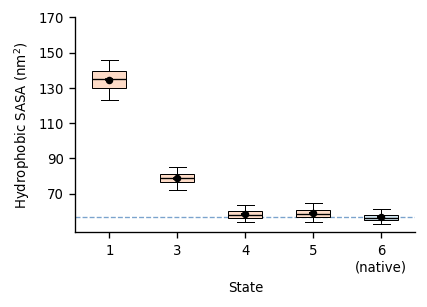

In [9]:
scheme = "Gfiltered"
sub = summary[summary["scheme"] == scheme]

fig, ax = plt.subplots(figsize=(3.6, 2.6))
data = [frames_by[scheme][rep] for rep in ANALYZED]

bp = ax.boxplot(data, positions=range(len(ANALYZED)), widths=0.5,
                whis=(5, 95), showfliers=False, patch_artist=True)
for i, rep in enumerate(ANALYZED):
    face = "#d1e5f0" if rep == NATIVE_REP else "#fddbc7"
    bp["boxes"][i].set(facecolor=face, edgecolor="black", linewidth=0.6)
    bp["medians"][i].set(color="black", linewidth=0.8)
    for part in ("whiskers", "caps"):
        for art in bp[part]:
            art.set(color="black", linewidth=0.6)

    row = sub.loc[sub["state_reported"] == rep].iloc[0]
    ax.errorbar(i, row["mean"],
                yerr=[[row["mean"] - row["ci95_low"]],
                      [row["ci95_high"] - row["mean"]]],
                fmt="o", ms=3.5, color="black", capsize=2.5, lw=1, zorder=3)

ax.axhline(sub.loc[sub["state_reported"] == NATIVE_REP, "mean"].iloc[0],
           color="#2166ac", ls="--", lw=0.8, alpha=0.6, zorder=1)
ax.set_xticks(range(len(ANALYZED)))
ax.set_xticklabels([f"{r}\n(native)" if r == NATIVE_REP else str(r) for r in ANALYZED])
ax.set_xlabel("State")
ax.set_ylabel("Hydrophobic SASA (nm$^2$)")
ax.spines[["top", "right"]].set_visible(False)

ax.set_yticks([70, 90, 110, 130, 150, 170])

fig.tight_layout()
fig.savefig(OUT_DIR / "hyd_sasa_by_state.png")
fig.savefig(OUT_DIR / "hyd_sasa_by_state.pdf")
plt.show()

### What the figure shows

Each observation is **one frame's** hydrophobic SASA (nm²), pooled across all 50
trajectories in the final 200 ns; for the non-native states only frames with `G > 0` are
included.

| element | meaning |
|---|---|
| box | 25th–75th percentile of frames (interquartile range) — the middle half of the distribution |
| line inside the box | median (50th percentile) |
| whiskers | 5th and 95th percentiles (set explicitly, *not* matplotlib's default 1.5×IQR) |
| beyond the whiskers | nothing is drawn — the most extreme 10% of frames (bottom 5%, top 5%) are suppressed |
| black marker | mean of the pooled frames |
| caps on the black marker | bootstrap 95% CI of that mean |
| dashed blue line | native-state mean, for reference |

The box describes how much hydrophobic SASA **fluctuates between structures** within a
state. It is not uncertainty in the state mean — that is the black marker's CI, which is
30–200× narrower than the whisker span (0.04–0.47 nm² wide) and therefore smaller than
the marker drawn over it, i.e. not visible at this scale.

Consequently the near-native states 4 and 5 sit a mean +2.1 and +2.4 nm² above native —
separated far beyond their confidence intervals — while their frame distributions still
overlap the native distribution almost entirely.

## Step 6c — Alternative figure: violin

Same data, drawn so nothing can be mistaken for an error bar. The violin is a kernel
density estimate of the frame distribution, the solid horizontal line inside each violin
is that state's mean, and the dashed blue line is the native mean carried across for
reference. No confidence intervals are drawn — at this scale they are 0.04–0.47 nm² wide
and would be invisible anyway.

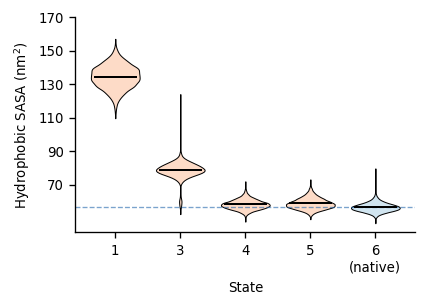

In [10]:
fig, ax = plt.subplots(figsize=(3.6, 2.6))
data = [frames_by[scheme][rep] for rep in ANALYZED]

parts = ax.violinplot(data, positions=range(len(ANALYZED)), widths=0.75,
                      showextrema=False, showmeans=False, showmedians=False)

for i, rep in enumerate(ANALYZED):
    body = parts["bodies"][i]
    body.set_facecolor("#d1e5f0" if rep == NATIVE_REP else "#fddbc7")
    body.set_edgecolor("black")
    body.set_linewidth(0.6)
    body.set_alpha(1.0)

    # solid line = mean of this state
    m = sub.loc[sub["state_reported"] == rep, "mean"].iloc[0]
    ax.hlines(m, i - 0.33, i + 0.33, color="black", lw=1.2, zorder=3)

# dashed line = native mean, for reference
ax.axhline(sub.loc[sub["state_reported"] == NATIVE_REP, "mean"].iloc[0],
           color="#2166ac", ls="--", lw=0.8, alpha=0.6, zorder=1)

ax.set_xticks(range(len(ANALYZED)))
ax.set_xticklabels([f"{r}\n(native)" if r == NATIVE_REP else str(r) for r in ANALYZED])
ax.set_xlabel("State")
ax.set_ylabel("Hydrophobic SASA (nm$^2$)")
ax.set_yticks([70, 90, 110, 130, 150, 170])
ax.spines[["top", "right"]].set_visible(False)

fig.tight_layout()
fig.savefig(OUT_DIR / "hyd_sasa_by_state_violin.png")
fig.savefig(OUT_DIR / "hyd_sasa_by_state_violin.pdf")
plt.show()

## Step 6b — Write the report

In [11]:
PRIMARY = "Gfiltered"
summ_p = summary[summary["scheme"] == PRIMARY]
native_row = summ_p.loc[summ_p["state_reported"] == NATIVE_REP].iloc[0]

excluded_labels = [to_reported(r) for r in EXCLUDED_RAW]
excluded_note = (
    "State " + ", ".join(str(s) for s in excluded_labels)
    + " is not populated in the final 200 ns and is therefore absent from all "
      "comparisons, tables and figures below.\n"
)

lines = [
    "# M3 - Hydrophobic SASA by state (final 200 ns)",
    "",
    "## Methods",
    "",
    f"Solvent-accessible surface area was taken from the existing per-residue SASA arrays "
    f"(mdtraj Shrake-Rupley, `mode='residue'`) computed on the backmapped trajectories of "
    f"GDI1/P39958, restricted to the final {N_LAST_200NS * FRAME_PS / 1000:.0f} ns "
    f"({N_LAST_200NS} frames at {FRAME_PS:g} ps/frame) of each of the {n_traj} trajectories. "
    f"Hydrophobic SASA was calculated per frame as the summed residue-level SASA over the "
    f"{int(hydrophobic_mask.sum())} residues of type "
    + ", ".join(sorted(HYDROPHOBIC)) + ".",
    "",
    "Frames were assigned to MSM macrostates using `meta_dtrajs`. To keep this analysis on "
    "the same structures as the reported state populations, non-native frames were included "
    f"only when an entanglement was present (G > {G_THRESHOLD:g}) and native frames were "
    "included unconditionally, matching the frame selection used for the state-population "
    "figure.",
    "",
    "Because the input is residue-level, this quantity includes both backbone and side-chain "
    "contributions for those residues and cannot be decomposed into the two. SASA was computed "
    "on a heavy-atom model without explicit hydrogens, so absolute values are systematically "
    "larger than for a fully protonated structure; comparisons between states are unaffected.",
    "",
    f"Statistics are pooled over frames: means are frame means, 95% confidence intervals are "
    f"percentile bootstrap over frames ({N_BOOT:,} resamples), and p-values are permutation "
    f"tests of the difference in frame means against the native state ({N_PERM:,} "
    f"permutations). Frames {FRAME_PS:g} ps apart are autocorrelated, so these intervals "
    f"characterise the pooled frame sample rather than independent observations of each state.",
    "",
    excluded_note,
    "## State population",
    "",
    population[~population["state_raw"].isin(EXCLUDED_RAW)].round(4).to_markdown(index=False),
    "",
    "`pop_panelB` reproduces the published state populations and is the population these "
    "SASA values correspond to; `pop_all` is the unconditional frame population of each "
    "state, and `frac_frames_kept` is the fraction of each state's frames retained by the "
    f"G > {G_THRESHOLD:g} condition.",
    "",
    "## Hydrophobic SASA by state",
    "",
    summary.round(2).to_markdown(index=False),
    "",
    f"Native state ({NATIVE_REP}) mean: {native_row['mean']:.1f} nm^2 "
    f"(95% CI {native_row['ci95_low']:.1f}-{native_row['ci95_high']:.1f}).",
    "",
    "## Comparison against the native state",
    "",
    perm.round(5).to_markdown(index=False),
    "",
    "p-values at `p_floor` have bottomed out against the number of permutations and should "
    "be quoted as an upper bound, not literally.",
    "",
    "## Interpretation",
    "",
    "TODO - write from the numbers above.",
    "",
    "Permitted framing: an absence of increased hydrophobic exposure is *consistent with* "
    "compact near-native misfolded states lacking strong hydrophobic-exposure recognition "
    "signals. Not permitted: any claim that these data demonstrate chaperone evasion, "
    "reduced degradation, or proteostasis bypass - none of those were measured here.",
    "",
]

report_path = OUT_DIR / "M3_report.md"
report_path.write_text("\n".join(lines))
print(f"wrote {report_path}\n")
print("\n".join(lines[:14]))

wrote /storage/home/qzv5006/group/Research_data/Aging_project/R1_analysis/M3_v2/outputs/M3_report.md

# M3 - Hydrophobic SASA by state (final 200 ns)

## Methods

Solvent-accessible surface area was taken from the existing per-residue SASA arrays (mdtraj Shrake-Rupley, `mode='residue'`) computed on the backmapped trajectories of GDI1/P39958, restricted to the final 200 ns (2666 frames at 75 ps/frame) of each of the 50 trajectories. Hydrophobic SASA was calculated per frame as the summed residue-level SASA over the 189 residues of type ALA, CYS, GLY, ILE, LEU, MET, PHE, TRP, VAL.

Frames were assigned to MSM macrostates using `meta_dtrajs`. To keep this analysis on the same structures as the reported state populations, non-native frames were included only when an entanglement was present (G > 0) and native frames were included unconditionally, matching the frame selection used for the state-population figure.

Because the input is residue-level, this quantity includes both backbone and 

---

**Interpretation ceiling.** This analysis measures exposed hydrophobic surface, a structural
property. It does not measure chaperone binding, ubiquitination, or degradation flux. The
`Interpretation` section of `outputs/M3_report.md` is deliberately left as a TODO — fill it
in from the numbers rather than from the hypothesis.

**Known caveat to state in the response:** hydrophobic SASA tracks overall chain expansion
closely (r ~ 0.997 with total SASA in these trajectories), so a difference between states
partly reflects compactness rather than hydrophobic exposure specifically.